한글 폰트 설정

In [ ]:
# ❶ OS 패키지 목록 업데이트
!sudo apt-get update -y

# ❷ 구글 Nanum 글꼴 설치
!sudo apt-get install -y fonts-nanum

Get:1 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:2 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:3 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease [1,581 B]
Hit:4 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:5 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:6 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Get:7 http://archive.ubuntu.com/ubuntu jammy-backports InRelease [127 kB]
Hit:8 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:9 https://ppa.launchpadcontent.net/graphics-drivers/ppa/ubuntu jammy InRelease
Get:10 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  Packages [1,724 kB]
Hit:11 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Get:12 http://security.ubuntu.com/ubuntu jammy-security/universe amd64 Packages [1,245 kB]
Get:13 http://security.ubuntu.com/ubun

In [ ]:
import matplotlib.pyplot as plt
from matplotlib import font_manager, rcParams

# ① 시스템 글꼴 목록에서 Nanum Gothic 확인
font_manager.findfont("NanumGothic")   # 경로가 뜨면 설치 성공

# ② 전역 설정
rcParams["font.family"] = "NanumGothic"
rcParams["axes.unicode_minus"] = False  # 마이너스 기호 깨짐 방지



*  ICD-9,10 flag 변수 생성하고 원핫인코딩
*  desc 칼럼 냅두고 원핫 인코딩 (desc_lower, 유방암 code는 드랍)
*  tumor_site 칼럼 생성하고 라벨인코딩


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Introduction

In [ ]:
# Import Libraries

import numpy as np # linear algebra
import pandas as pd # for data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns # for data visualization
import matplotlib.pyplot as plt # for data visulaization
plt.rc('font', family='NanumBarunGothic')
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
!pip install catboost
import catboost
import xgboost
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from sklearn.ensemble import RandomForestClassifier, VotingClassifier

from collections import defaultdict

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 8.0 MB/s eta 0:00:00


In [ ]:
import warnings

# Ignore all warnings
warnings.filterwarnings("ignore")

# Load datasets

In [ ]:
# Load Competiton Datasets and drop breast_cancer_diagnosis_code
df = pd.read_csv("/content/drive/MyDrive/2025_DataMining/WiDS/training.csv")
tdf = pd.read_csv("/content/drive/MyDrive/2025_DataMining/WiDS/test.csv")
ss = pd.read_csv("/content/drive/MyDrive/2025_DataMining/WiDS/sample_submission.csv")

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12906 entries, 0 to 12905
Data columns (total 83 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   patient_id                             12906 non-null  int64  
 1   patient_race                           6521 non-null   object 
 2   payer_type                             11103 non-null  object 
 3   patient_state                          12855 non-null  object 
 4   patient_zip3                           12906 non-null  int64  
 5   patient_age                            12906 non-null  int64  
 6   patient_gender                         12906 non-null  object 
 7   bmi                                    3941 non-null   float64
 8   breast_cancer_diagnosis_code           12906 non-null  object 
 9   breast_cancer_diagnosis_desc           12906 non-null  object 
 10  metastatic_cancer_diagnosis_code       12906 non-null  object 
 11  me

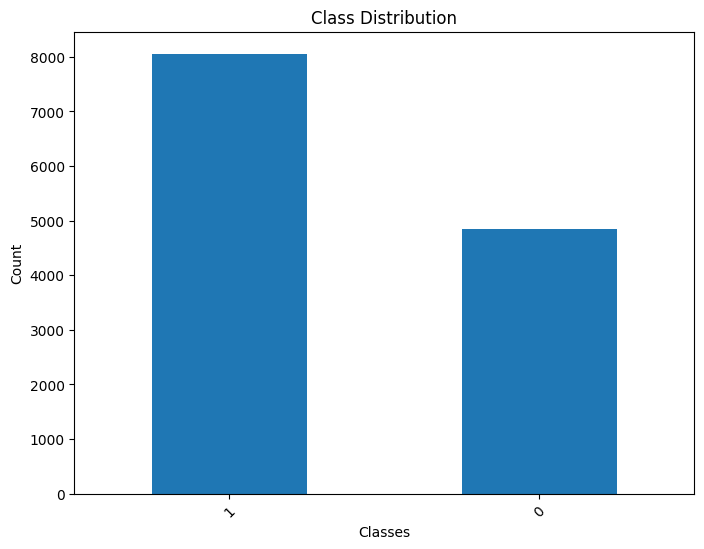

In [ ]:
target = "DiagPeriodL90D"

# Count the occurrences of each class
class_counts = df[target].value_counts()

# Plot the class distribution
plt.figure(figsize=(8, 6))
class_counts.plot(kind='bar')
plt.title('Class Distribution')
plt.xlabel('Classes')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

# Feature Engineering

### NO2, PM25, commute_time - Missing Value

- patient_zip2 기반의 평균값으로 대체

In [ ]:
# patient_zip2 파생 변수 생성
df['patient_zip2'] = df['patient_zip3'].astype(str).str[:2]
tdf['patient_zip2'] = tdf['patient_zip3'].astype(str).str[:2]


# 전처리할 컬럼 리스트
target_cols = ['N02', 'PM25', 'commute_time']

# df, tdf 각각에 대해 그룹별 평균으로 결측치 채우기
for dataset in [df, tdf]:
    for col in target_cols:
        dataset[col] = dataset.groupby('patient_zip2')[col].transform(lambda x: x.fillna(x.mean()))

In [ ]:
# 각 컬럼의 결측치 개수 출력
for col in ['N02', 'PM25', 'commute_time']:
    missing_count = df[col].isnull().sum()
    print(f"{col} 결측치 개수: {missing_count}")

N02 결측치 개수: 0
PM25 결측치 개수: 0
commute_time 결측치 개수: 0


### NO2 x PM25 x commute_time + MinMax Scaling

In [ ]:
from sklearn.preprocessing import MinMaxScaler

# 스케일링 대상 컬럼
cols = ['N02', 'PM25', 'commute_time']

# MinMax 스케일러 정의
scaler = MinMaxScaler()

# df 정규화
df_scaled = pd.DataFrame(scaler.fit_transform(df[cols]), columns=cols, index=df.index)
df['N02xPM25xcommute_time'] = df_scaled['N02'] * df_scaled['PM25'] * df_scaled['commute_time']

# tdf 정규화 (df 기준으로 transform)
tdf_scaled = pd.DataFrame(scaler.transform(tdf[cols]), columns=cols, index=tdf.index)
tdf['N02xPM25xcommute_time'] = tdf_scaled['N02'] * tdf_scaled['PM25'] * tdf_scaled['commute_time']

### train + test

In [ ]:
# define target variable and categorical features
cat_cols = list(tdf.columns[tdf.dtypes=="object"])
cols = [col for col in tdf.columns if col not in ["patient_id"]]
tdf[target] = np.nan

# concatenate train and test set
df = pd.concat([df,tdf[df.columns]],axis=0)

### clust + is_female

In [ ]:
df["clust"]=(df.metastatic_cancer_diagnosis_code.str.len()==4).astype("int")
df["is_female"] = df.breast_cancer_diagnosis_desc.str.contains("female").astype("int")
df["is_female"].value_counts()

,count
is_female,
1,18665
0,33


### meta_code4

In [ ]:
# meta 칼럼에서 5자리 값을 4자리로 변환
df['meta_code4'] = df['metastatic_cancer_diagnosis_code'].astype(str).apply(lambda x: x[:4] if len(x) >= 5 else x)

# 결과 확인
print(df['meta_code4'].nunique())
print(df['meta_code4'].value_counts())

#metastatic_cancer_diagnosis_code 드랍하기
df = df.drop(columns=['metastatic_cancer_diagnosis_code'])

27
meta_code4
C773    10223
C795     2760
C798     1196
C779     1095
C780      910
C787      533
C799      399
C793      389
C792      239
C771      226
C770      192
C782      117
C778      116
C786       57
C781       40
C772       39
C794       29
C796       27
C788       25
C785       25
C797       17
C775       14
C790        8
C791        7
C784        6
C783        5
C774        4
Name: count, dtype: int64


### ICD_version

In [ ]:
# ICD_version 파생변수 생성 (ICD-10이면 0, ICD-9이면 1)

df['ICD_version'] = np.where(df['breast_cancer_diagnosis_code'].astype(str).str.startswith('C'), 0, 1)
print(df['ICD_version'].value_counts())

ICD_version
0    14333
1     4365
Name: count, dtype: int64


## tumor_site

In [ ]:
df['desc_lower'] = df['breast_cancer_diagnosis_desc'].str.lower()

In [ ]:
df['tumor_site'] = np.select(
    [
        df['desc_lower'].str.contains('upper-inner'),
        df['desc_lower'].str.contains('lower-inner'),
        df['desc_lower'].str.contains('upper-outer'),
        df['desc_lower'].str.contains('lower-outer'),
        df['desc_lower'].str.contains('axillary tail'),
        df['desc_lower'].str.contains('central portion') | df['desc_lower'].str.contains('nipple') | df['desc_lower'].str.contains('areola'),
        df['desc_lower'].str.contains('overlapping') | df['desc_lower'].str.contains('ovrlp'),
        df['desc_lower'].str.contains('unspecified') | df['desc_lower'].str.contains('unsp')
    ],
    [
        'Upper-inner',
        'Lower-inner',
        'Upper-outer',
        'Lower-outer',
        'Axillary tail',
        'Central',
        'Overlapping',
        'Unspecified'
    ],
    default='Unspecified'
)
print(df['tumor_site'].value_counts())

tumor_site
Unspecified      10624
Upper-outer       3322
Overlapping       1380
Central           1071
Upper-inner       1003
Lower-outer        700
Lower-inner        489
Axillary tail      109
Name: count, dtype: int64


## patient_race - Missing Value

### tumor_site - race 결측치 채우기 위해 사용

In [ ]:
df['tumor_site'].isnull().sum()

np.int64(0)

### 확률 데이터 생성

- **P(tumor_site | race) 확률 데이터 프레임 생성**

In [ ]:
# 1. 논문 기반 6개 종양 위치 확률 (단위: %)
tumor_sites_main = ['Central', 'Upper-inner', 'Lower-inner', 'Upper-outer', 'Lower-outer', 'Axillary tail', 'Unspecified', 'Overlapping']
tumor_sites_all = tumor_sites_main

# 2. 인종 목록
races = ['White', 'Black', 'Asian', 'Hispanic', 'Other']

# 3. 논문 기반 확률 (6개 부위만)
paper_data = {
    'Central':      [8.5,   7.7,  10.3,  8.9,  16.79],
    'Upper-inner':  [16.6, 17.0,  19.7, 17.7,  13.87],
    'Lower-inner':  [8.3,   9.8,   8.3,  8.2,   6.57],
    'Upper-outer':  [54.9, 53.4,  50.6, 53.6,  51.46],
    'Lower-outer':  [10.7, 10.8,  10.4, 10.7,  10.58],
    'Axillary tail':[1.0,   1.3,   0.7,  0.8,   0.73],
    'Unspecified':  [55.72, 55.88, 64.62, 62.61, 49.93],
    'Overlapping':  [9.43,  10.53, 10.03,  7.48,  9.84]
}

# 4. 데이터프레임 생성
tumor_site_prob_per_race = pd.DataFrame(paper_data, index=races).T
tumor_site_prob_per_race.index.name = "Tumor Site"

# 5. 결과 출력
print("🎯 인종별 유방암 종양 위치 확률 테이블 (%):")
print(tumor_site_prob_per_race)

🎯 인종별 유방암 종양 위치 확률 테이블 (%):
               White  Black  Asian  Hispanic  Other
Tumor Site                                         
Central         8.50   7.70  10.30      8.90  16.79
Upper-inner    16.60  17.00  19.70     17.70  13.87
Lower-inner     8.30   9.80   8.30      8.20   6.57
Upper-outer    54.90  53.40  50.60     53.60  51.46
Lower-outer    10.70  10.80  10.40     10.70  10.58
Axillary tail   1.00   1.30   0.70      0.80   0.73
Unspecified    55.72  55.88  64.62     62.61  49.93
Overlapping     9.43  10.53  10.03      7.48   9.84


- **P(zip3 | race)**

In [ ]:
## P(zip3 | race) 데이터 프레임


# 1. 결측치가 없는 행만 필터링
df_valid = df[df['patient_race'].notna()].copy()

# 2. 인종과 patient_zip3에 따른 joint frequency table 생성
zip3_race_counts = (
    df_valid
    .groupby(['patient_race', 'patient_zip3'])
    .size()
    .unstack(fill_value=0)
)

# 3. 인종별로 zip3 값의 확률 계산 (행 기준 정규화)
zip3_given_race_prob = zip3_race_counts.div(zip3_race_counts.sum(axis=1), axis=0)

# 4. 결과 확인
print("🎯 P(zip3 | race) 조건부 확률 테이블:")
zip3_given_race_prob

🎯 P(zip3 | race) 조건부 확률 테이블:


patient_zip3,101,103,104,105,106,107,108,109,110,111,...,982,983,984,985,986,988,989,990,991,992
patient_race,,,,,,,,,,,,,,,,,,,,,
Asian,0.000000,0.003846,0.011538,0.000000,0.000000,0.000000,0.001923,0.000000,0.000000,0.000000,...,0.001923,0.001923,0.007692,0.000000,0.003846,0.000000,0.000000,0.000000,0.00000,0.000000
Black,0.000000,0.001277,0.014049,0.001277,0.000000,0.001277,0.000000,0.000000,0.000000,0.001277,...,0.000000,0.000000,0.000639,0.000000,0.000639,0.000000,0.000000,0.000000,0.00000,0.000639
Hispanic,0.000000,0.000000,0.010204,0.001701,0.000000,0.001701,0.000850,0.001701,0.000000,0.000850,...,0.000000,0.000850,0.000000,0.000000,0.000850,0.003401,0.001701,0.000000,0.00000,0.000000
Other,0.000000,0.001046,0.005230,0.002092,0.000000,0.000000,0.000000,0.002092,0.001046,0.001046,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.001046,0.000000,0.00000,0.000000
White,0.000193,0.001733,0.002888,0.001925,0.000193,0.000193,0.000385,0.000770,0.000578,0.000963,...,0.003658,0.001733,0.001155,0.000963,0.002118,0.001540,0.000578,0.000578,0.00077,0.001540


- **P(race)**

In [ ]:
race_prob = df['patient_race'].value_counts(normalize=True).reindex(races, fill_value=0)

race_prob

,proportion
patient_race,
White,0.551849
Black,0.166383
Asian,0.055249
Hispanic,0.124947
Other,0.101572


### 결측치 채우기

In [ ]:
## df (zip3, 확률 0.7 이상일 때만 대체)


# 대상 인종 및 종양 위치
races = ['White', 'Black', 'Asian', 'Hispanic', 'Other']
tumor_sites_all = ['Central', 'Upper-inner', 'Lower-inner', 'Upper-outer', 'Lower-outer',
                   'Axillary tail', 'Unspecified', 'Overlapping']

# 1. 결측치 행 추출
missing = df[df['patient_race'].isna()].copy()
total_missing = len(missing)

# 2. 추론
filled_count = 0
predicted_labels = {}
threshold = 0.7

for idx, row in missing.iterrows():
    tumor = row['tumor_site']
    zip3 = row['patient_zip3']

    probs = {}
    for race in races:
        p_tumor = tumor_site_prob_per_race.at[tumor, race] / 100 if tumor in tumor_site_prob_per_race.index else 0
        p_zip = zip3_given_race_prob.at[race, zip3] if zip3 in zip3_given_race_prob.columns else 0
        p_race = race_prob[race]
        probs[race] = p_tumor * p_zip * p_race

    total_prob = sum(probs.values())
    if total_prob == 0:
        continue

    normalized_probs = {k: v / total_prob for k, v in probs.items()}
    best_race = max(normalized_probs, key=normalized_probs.get)
    max_prob = normalized_probs[best_race]

    if max_prob >= threshold:
        predicted_labels[idx] = best_race
        filled_count += 1

# 3. 실제 채우기
df.loc[predicted_labels.keys(), 'patient_race'] = pd.Series(predicted_labels)

# 4. 출력
print("✅ Naive Bayes 기반 인종 결측치 채우기 완료")
print(f"🔹 전체 결측치 수: {total_missing}")
print(f"🔹 채워진 결측치 수 (확률 ≥ {threshold}): {filled_count}")
print(f"🔹 채워진 비율: {round(filled_count / total_missing * 100, 2)}%")
print(f"🔸 남은 결측치 수: {df['patient_race'].isna().sum()}")

✅ Naive Bayes 기반 인종 결측치 채우기 완료
🔹 전체 결측치 수: 9286
🔹 채워진 결측치 수 (확률 ≥ 0.7): 3774
🔹 채워진 비율: 40.64%
🔸 남은 결측치 수: 4828


## Columns Drop (zip3 Groupby & others

In [ ]:
len(df.columns)

90

In [ ]:
# Drop some features

# List of columns to iterate over
columns_to_iterate = [col for col in df.columns if col not in ["patient_zip3", "N02xPM25xcommute_time"]]

# Iterate over each column
for col in columns_to_iterate:
    # Your code to operate on each column goes here
    df["check"]=df.groupby(["patient_zip3","N02xPM25xcommute_time"])[col].transform("nunique")
    if df["check"].max()==1:
        print("dropped ",col)
        df=df.drop(col,axis=1)
        # tdf=tdf.drop(col,axis=1)
df=df.drop("check",axis=1)

dropped  patient_gender
dropped  metastatic_first_novel_treatment
dropped  metastatic_first_novel_treatment_type
dropped  population
dropped  density
dropped  age_median
dropped  age_under_10
dropped  age_10_to_19
dropped  age_20s
dropped  age_30s
dropped  age_40s
dropped  age_50s
dropped  age_60s
dropped  age_70s
dropped  age_over_80
dropped  male
dropped  female
dropped  married
dropped  divorced
dropped  never_married
dropped  widowed
dropped  family_size
dropped  family_dual_income
dropped  income_household_median
dropped  income_household_under_5
dropped  income_household_5_to_10
dropped  income_household_10_to_15
dropped  income_household_15_to_20
dropped  income_household_20_to_25
dropped  income_household_25_to_35
dropped  income_household_35_to_50
dropped  income_household_50_to_75
dropped  income_household_75_to_100
dropped  income_household_100_to_150
dropped  income_household_150_over
dropped  income_household_six_figure
dropped  income_individual_median
dropped  home_owner

In [ ]:
df = df.drop(columns=[
    'Region', 'patient_zip3',
    'desc_lower',
    # 'breast_cancer_diagnosis_desc',
    'breast_cancer_diagnosis_code',
    # 'tumor_site'
])

In [ ]:
df.columns.to_list()

['patient_id',
 'patient_race',
 'payer_type',
 'patient_state',
 'patient_age',
 'bmi',
 'breast_cancer_diagnosis_desc',
 'Division',
 'DiagPeriodL90D',
 'N02xPM25xcommute_time',
 'clust',
 'is_female',
 'meta_code4',
 'ICD_version',
 'tumor_site']

In [ ]:
len(df.columns)

15

## One-Hot Encoding

In [ ]:
# One-Hot Encoding

categorical_cols = [
    col for col in df.columns
    if df[col].dtype == 'object' and col != 'tumor_site'
]

In [ ]:
categorical_cols

['patient_race',
 'payer_type',
 'patient_state',
 'breast_cancer_diagnosis_desc',
 'Division',
 'meta_code4']

In [ ]:
df = pd.get_dummies(df, columns=categorical_cols, drop_first=True, dtype="int")

## Label Encoding

In [ ]:
# 사용자 정의 순서에 따라 숫자 부여
tumor_site_order = {
    'Central': 7,
    'Overlapping': 6,
    'Axillary tail': 5,
    'Lower-outer': 4,
    'Upper-outer': 3,
    'Lower-inner': 2,
    'Upper-inner': 1,
    'Unspecified': 0
}

# 결측치는 가장 낮은 영향도와 비슷하게 처리 (예: Unspecified 취급)
df['tumor_site'] = df['tumor_site'].fillna('Unspecified')

# 사용자 정의 라벨 인코딩 적용
df['tumor_site'] = df['tumor_site'].map(tumor_site_order)

In [ ]:
# do label encoding for categorical columns
le = LabelEncoder()
for col in cat_cols:
    try:
        df[col]=le.fit_transform(df[col]).astype("int")
        print(col)
    except:
        continue

In [ ]:
tdf = df[df[target].isna()]
df = df[df[target].notna()]
len(df), len(tdf)
# 분리하는 코드

(12906, 5792)

# Data Cleaning

Zip code level metadata were dropped except product of N02,PM25 & Ozone

Data set contained missing values which we left unhandled


In [ ]:
len(df.columns)

149

In [ ]:
for col in df.columns:
    print(col)

patient_id
patient_age
bmi
DiagPeriodL90D
N02xPM25xcommute_time
clust
is_female
ICD_version
tumor_site
patient_race_Black
patient_race_Hispanic
patient_race_Other
patient_race_White
payer_type_MEDICAID
payer_type_MEDICARE ADVANTAGE
patient_state_AL
patient_state_AR
patient_state_AZ
patient_state_CA
patient_state_CO
patient_state_CT
patient_state_DC
patient_state_DE
patient_state_FL
patient_state_GA
patient_state_HI
patient_state_IA
patient_state_ID
patient_state_IL
patient_state_IN
patient_state_KS
patient_state_KY
patient_state_LA
patient_state_MA
patient_state_MD
patient_state_MI
patient_state_MN
patient_state_MO
patient_state_MS
patient_state_MT
patient_state_NC
patient_state_ND
patient_state_NE
patient_state_NH
patient_state_NJ
patient_state_NM
patient_state_NV
patient_state_NY
patient_state_OH
patient_state_OK
patient_state_OR
patient_state_PA
patient_state_PR
patient_state_RI
patient_state_SC
patient_state_SD
patient_state_TN
patient_state_TX
patient_state_UT
patient_state_VA
pat

# Modeling

In [ ]:
# ▶ CatBoost
modela = CatBoostClassifier(
    iterations = 500,
    silent = True,
    learning_rate = 0.05,
    depth = 10,
    eval_metric = 'AUC',
    random_seed = 42
)

# ▶ RandomForest
modelb = RandomForestClassifier(
    n_estimators = 200,
    max_depth = None,
    min_samples_split = 2,
    random_state = 42,
    n_jobs = -1
)

# ▶ XGBoost
modelc = XGBClassifier(
    learning_rate = 0.1,
    max_depth = 6,
    n_estimators = 100,
    subsample = 0.9
)

In [ ]:
# finalize features for training
drop_cols = ["patient_id", target, "patient_zip3", "patient_state"]
cols = list(set(df.columns) - set(drop_cols))

In [ ]:
print("모델 학습에 사용된 feature 개수:", len(cols))
print("사용된 feature 리스트:")
for col in cols:
    print(col)

모델 학습에 사용된 feature 개수: 147
사용된 feature 리스트:
meta_code4_C784
breast_cancer_diagnosis_desc_Malignant neoplasm of unsp site of right female breast
patient_state_CO
clust
patient_state_WA
meta_code4_C779
patient_state_TX
breast_cancer_diagnosis_desc_Malig neoplasm of upper-inner quadrant of unsp female breast
breast_cancer_diagnosis_desc_Malig neoplm of lower-outer quadrant of right female breast
meta_code4_C775
patient_state_AR
breast_cancer_diagnosis_desc_Malig neoplasm of lower-outer quadrant of left female breast
meta_code4_C790
breast_cancer_diagnosis_desc_Malignant neoplasm of ovrlp sites of left female breast
meta_code4_C781
patient_race_Other
meta_code4_C787
patient_state_MO
breast_cancer_diagnosis_desc_Malignant neoplasm of lower-outer quadrant of breast, female
meta_code4_C782
breast_cancer_diagnosis_desc_Secondary malignant neoplasm of breast
patient_state_AZ
breast_cancer_diagnosis_desc_Malignant neoplasm of overlapping sites of breast, female
meta_code4_C774
patient_state_IA
p

In [ ]:
# Define the number of folds
num_folds = 10
from sklearn.model_selection import StratifiedKFold
kf = StratifiedKFold(n_splits = num_folds, shuffle = True, random_state = 42)

In [ ]:
# use stacking method, define meta model
from sklearn.linear_model import LogisticRegression
meta_model = LogisticRegression()
meta_features = ['pred1','pred2','pred3']

In [ ]:
# Initialize empty dataframe to store predictions from all folds
predictions_from_folds = pd.DataFrame()
# Iterate over folds
for fold, (train_index, val_index) in enumerate(kf.split(df, df[target])):
    dfx, efx = df.iloc[train_index], df.iloc[val_index]
    # train and make predictions on train set
    efx["pred1"] = modela.fit(dfx[cols].values, dfx[target]).predict_proba(efx[cols].values)[:,1]
    efx["pred2"] = modelb.fit(dfx[cols].values, dfx[target]).predict_proba(efx[cols].values)[:,1]
    efx["pred3"] = modelc.fit(dfx[cols].values, dfx[target]).predict_proba(efx[cols].values)[:,1]
    # make predictions on test set
    tdf["pred1"] = modela.predict_proba(tdf[cols].values)[:,1]
    tdf["pred2"] = modelb.predict_proba(tdf[cols].values)[:,1]
    tdf["pred3"] = modelc.predict_proba(tdf[cols].values)[:,1]
    # train meta-models and make final predictions
    tdf["pred"] = meta_model.fit(efx[meta_features], efx[target]).predict_proba(tdf[meta_features])[:, 1]
    predictions_from_folds = pd.concat([predictions_from_folds,tdf], axis = 0)

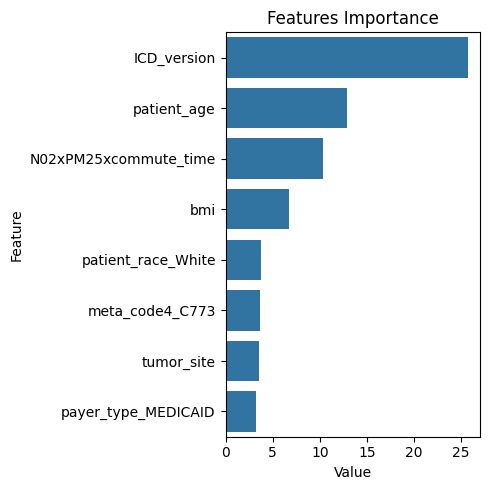

In [ ]:
# feature importance

feature_imp = pd.DataFrame(sorted(zip(modela.feature_importances_,cols)), columns = ['Value', 'Feature'])
feature_imp = feature_imp.sort_values("Value", ascending = False)
feature_imp = feature_imp.head(8)
feature_imp["Feature"] = feature_imp["Feature"]
plt.figure(figsize = (5, 5))
sns.barplot(x = "Value", y = "Feature", data = feature_imp.sort_values(by = "Value", ascending = False))
plt.title('Features Importance')
plt.tight_layout()
plt.savefig('cb_importances.png')
plt.show()

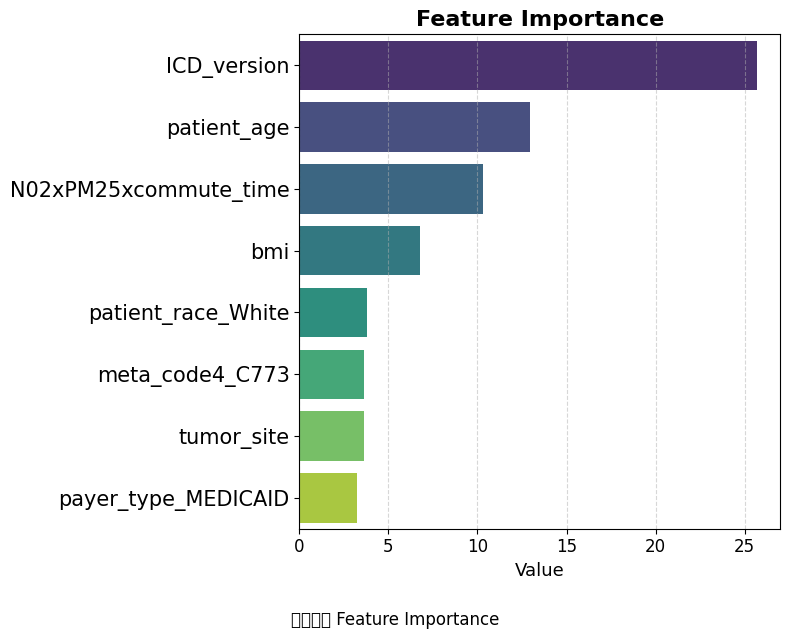

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 중요도 데이터 준비
feature_imp = pd.DataFrame(sorted(zip(modela.feature_importances_, cols)), columns=['Value', 'Feature'])
feature_imp = feature_imp.sort_values("Value", ascending=False).head(8)

# 시각화
plt.figure(figsize=(8, 6))
sns.barplot(
    x="Value",
    y="Feature",
    data=feature_imp,
    palette="viridis"
)

plt.title('Feature Importance', fontsize=16, weight='bold')
plt.xlabel('Value', fontsize=13)
plt.ylabel('')  # ✅ y축 라벨 제거
plt.xticks(fontsize=12)
plt.yticks(fontsize=15)
plt.grid(axis='x', linestyle='--', alpha=0.5)

# 캡션 추가
plt.figtext(0.5, -0.05, '개선작의 Feature Importance', ha='center', fontsize=12)

plt.tight_layout()
plt.savefig('cb_importances_with_caption.png', bbox_inches='tight')
plt.show()


In [ ]:
importance_values = modela.feature_importances_

importance_values_df = pd.DataFrame({
    'Feature': cols,
    'Importance': importance_values
})

# ✅ 중요도 기준 내림차순 정렬
importance_values_df = importance_values_df.sort_values(by='Importance', ascending=False)

importance_values_df

,Feature,Importance
30,ICD_version,25.706476
25,patient_age,12.935714
31,N02xPM25xcommute_time,10.334577
139,bmi,6.764076
55,patient_race_White,3.770276
...,...,...
87,breast_cancer_diagnosis_desc_Malignant neoplas...,0.000000
104,breast_cancer_diagnosis_desc_Malignant neoplas...,0.000000
93,breast_cancer_diagnosis_desc_Malignant neoplas...,0.000000
118,breast_cancer_diagnosis_desc_Malignant neoplas...,0.000000


In [ ]:
# 확인하고 싶은 feature 목록
target_features = ['N02xPM25xcommute_time', 'patient_race_White', 'patient_race_Black']

# 해당 feature들만 필터링
selected_importance_df = importance_values_df[importance_values_df['Feature'].isin(target_features)]

selected_importance_df


,Feature,Importance
31,N02xPM25xcommute_time,10.334577
55,patient_race_White,3.770276
37,patient_race_Black,1.313051


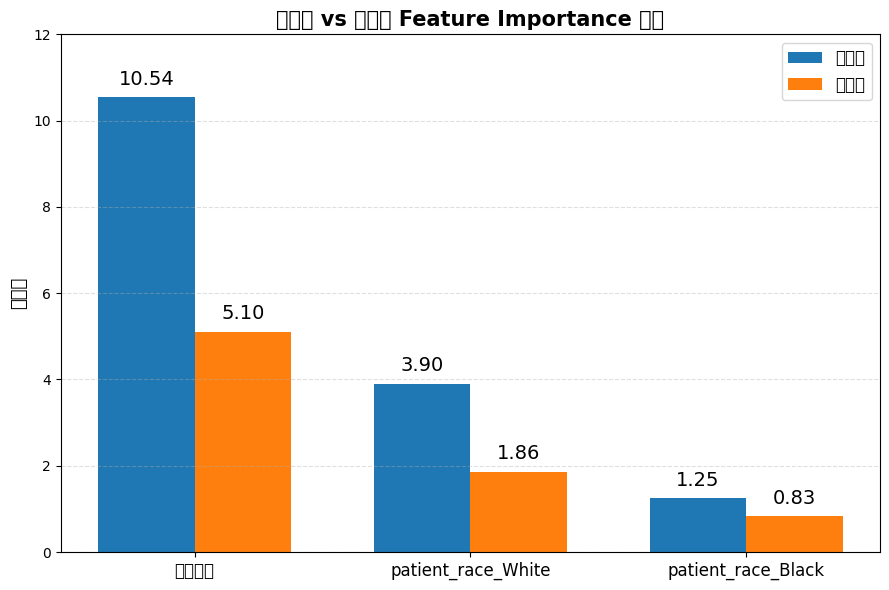

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# ✅ 예시 DataFrame
df1 = pd.DataFrame({
    'Feature': ['환경변수', 'patient_race_White', 'patient_race_Black'],  # 이름 변경
    'Importance': [10.538431, 3.899000, 1.248978]
})
df1.set_index('Feature', inplace=True)

df2 = pd.DataFrame({
    'Feature': ['환경변수', 'patient_race_White', 'patient_race_Black'],  # 이름 변경
    'Importance': [5.099998, 1.862472, 0.825383]
})
df2.set_index('Feature', inplace=True)

# ✅ 병합 및 이름 변경
df_combined = pd.concat([df1, df2], axis=1)
df_combined.columns = ['개선작', '수상작']
df_combined = df_combined.reset_index()

# ✅ 시각화
x = np.arange(len(df_combined))
width = 0.35

plt.figure(figsize=(9, 6))
bars1 = plt.bar(x - width/2, df_combined['개선작'], width, label='개선작')
bars2 = plt.bar(x + width/2, df_combined['수상작'], width, label='수상작')

# ✅ 값 레이블 추가
for bar in bars1:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
             f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=14)
for bar in bars2:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
             f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=14)

# ✅ y축 범위 설정
plt.ylim(0, 12)


# ✅ 축 및 스타일
plt.xticks(x, df_combined['Feature'], fontsize=12)
plt.ylabel('중요도', fontsize=13)
plt.title('개선작 vs 수상작 Feature Importance 비교', fontsize=15, weight='bold')
plt.legend(fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()


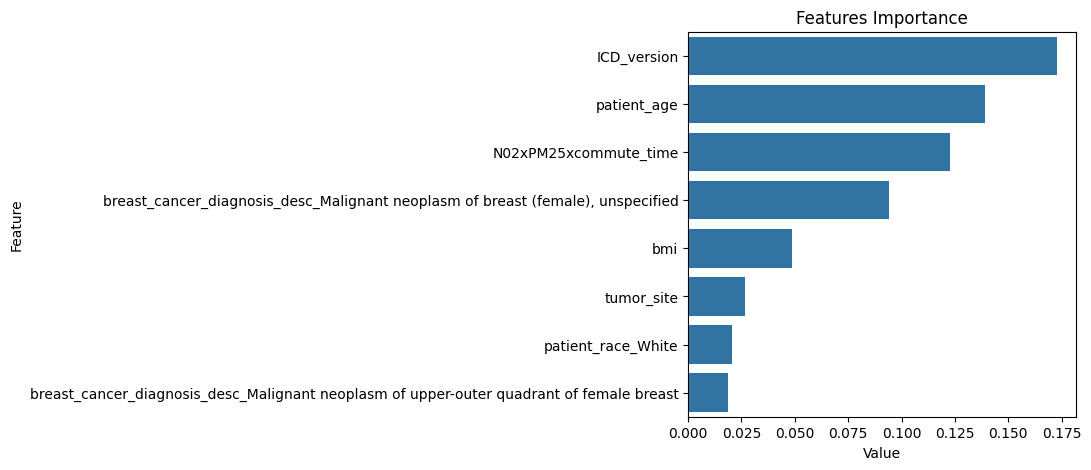

In [ ]:
# feature importance

feature_imp = pd.DataFrame(sorted(zip(modelb.feature_importances_,cols)), columns = ['Value', 'Feature'])
feature_imp = feature_imp.sort_values("Value", ascending = False)
feature_imp = feature_imp.head(8)
feature_imp["Feature"] = feature_imp["Feature"]
plt.figure(figsize = (5, 5))
sns.barplot(x = "Value", y = "Feature", data = feature_imp.sort_values(by = "Value", ascending = False))
plt.title('Features Importance')
plt.tight_layout()
plt.savefig('cb_importances.png')
plt.show()

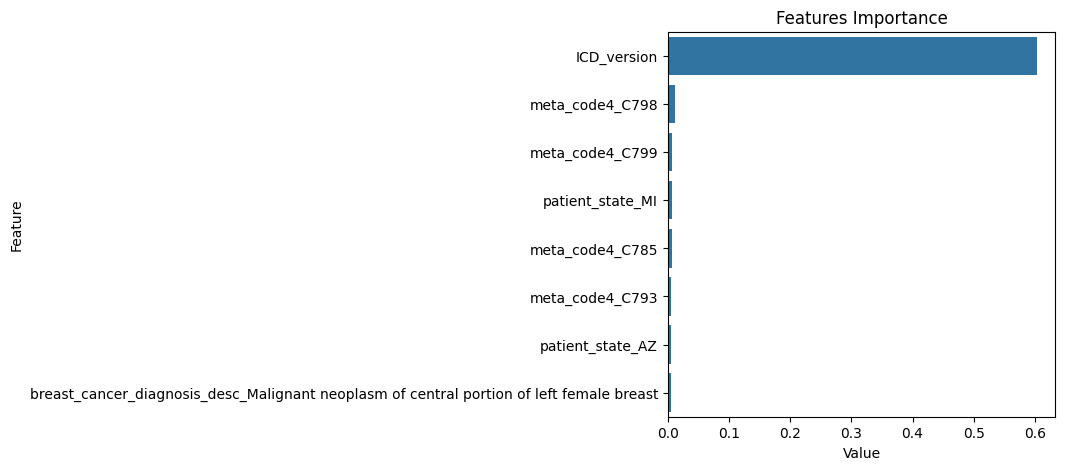

In [ ]:
# feature importance

feature_imp = pd.DataFrame(sorted(zip(modelc.feature_importances_,cols)), columns = ['Value', 'Feature'])
feature_imp = feature_imp.sort_values("Value", ascending = False)
feature_imp = feature_imp.head(8)
feature_imp["Feature"] = feature_imp["Feature"]
plt.figure(figsize = (5, 5))
sns.barplot(x = "Value", y = "Feature", data = feature_imp.sort_values(by = "Value", ascending = False))
plt.title('Features Importance')
plt.tight_layout()
plt.savefig('cb_importances.png')
plt.show()

# Submission

In [ ]:
# blend predictions from all folds
final_predictions = predictions_from_folds.groupby("patient_id").mean().reset_index()
final_predictions[target] = final_predictions["pred"].values
final_predictions[ss.columns].to_csv("final_predictions.csv", index = None)

In [ ]:
from google.colab import files
files.download("final_predictions.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

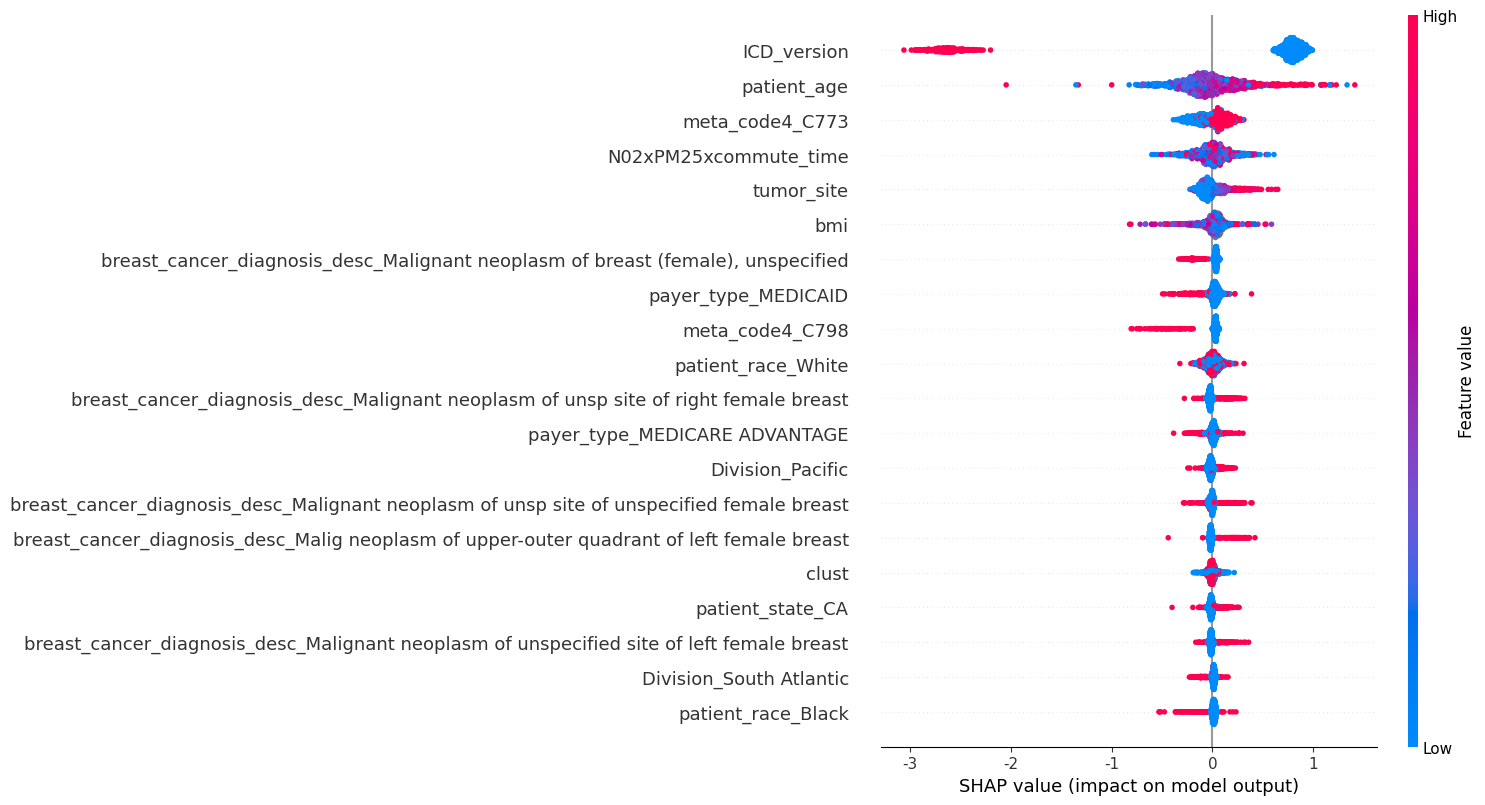

In [ ]:
# prompt: shap value 값을 확인하고 싶어

!pip install shap

import shap

# CatBoost 모델의 SHAP Values 계산
# 모델 학습에 사용된 데이터 (dfx) 와 SHAP 값을 계산할 데이터 (efx 또는 tdf) 필요
# 여기서는 예시로 전체 학습 데이터 (df)를 사용하지만, 실제로는 검증 또는 테스트 데이터셋에 적용하는 것이 일반적입니다.
X_train_shap = df[cols]
X_display = X_train_shap.sample(frac=0.1, random_state=42) # 계산 속도를 위해 샘플링

# CatBoost Explainer 생성
explainer = shap.TreeExplainer(modela)

# SHAP Values 계산
# 샘플링된 데이터에 대해 계산
shap_values = explainer.shap_values(X_display)

# SHAP Values 시각화 (summary plot)
# 전반적인 feature importance 및 각 feature의 영향 방향 확인
shap.summary_plot(shap_values, X_display)

# 단일 예측에 대한 SHAP Values 시각화 (force plot)
# 특정 데이터 포인트에 대해 각 feature가 예측에 미치는 영향 확인
# 예: 첫 번째 데이터 포인트 (index 0)
# force_plot은 JavaScript가 필요하므로 Colab에서 `initjs()`를 먼저 실행
shap.initjs()
shap.force_plot(explainer.expected_value, shap_values[0,:], X_display.iloc[0,:])

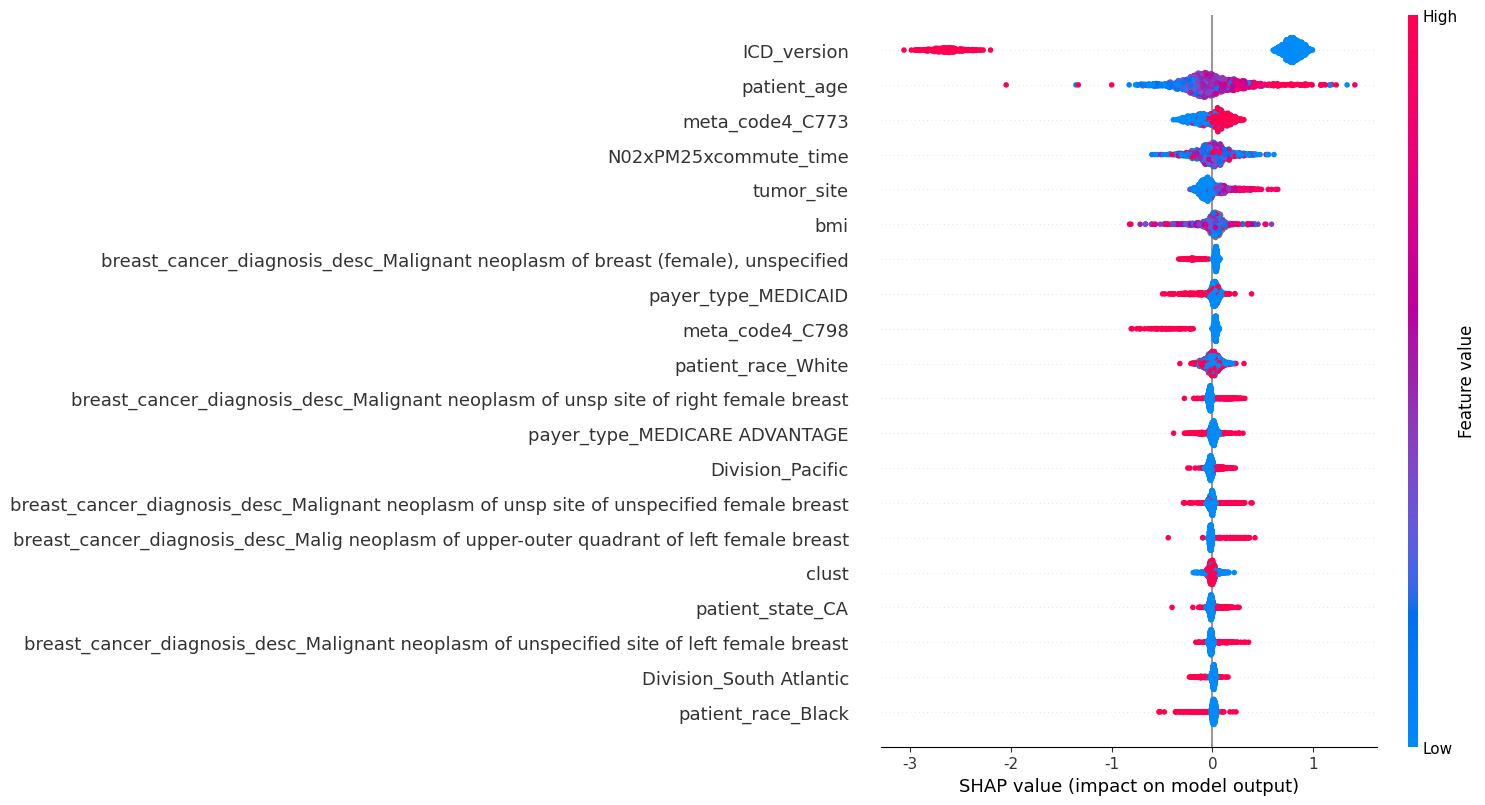

TypeError: The shap_values argument must be an Explanation object, Cohorts object, or dictionary of Explanation objects!

In [ ]:
# 1) 패키지 설치 (최초 1회)
!pip install -q shap catboost  # catboost가 이미 있다면 생략

# 2) 라이브러리 로드
import shap, pandas as pd, numpy as np
from catboost import CatBoostClassifier, Pool
import matplotlib.pyplot as plt

# 3) (예시) 데이터·모델 준비 ─ 이미 학습된 modela가 있다면 생략
# --------------------------------------------------------------
# X, y = ...  # 데이터프레임 & 레이블 준비
# modela = CatBoostClassifier(silent=True)
# modela.fit(X, y)

# 4) SHAP 계산용 샘플링 ─ 너무 크면 시간&메모리 ↑
X_all   = df[cols]                       # 전체 or 검증·테스트
X_disp  = X_all.sample(frac=0.10, random_state=42)

explainer   = shap.TreeExplainer(modela)
shap_values = explainer.shap_values(X_disp)

# 5) 전역 요약 시각화 ------------------------------------------
# (a) Summary plot ─ 점 분포 + feature 순서
shap.summary_plot(shap_values, X_disp, show=False)  # show=False → 저장 후 따로 plt.show()
plt.tight_layout()
plt.savefig("shap_summary.png", dpi=300)
plt.show()

# (b) Bar plot ─ 평균 절대값만 보고 싶을 때
shap.plots.bar(shap_values, max_display=20)

# 6) 개별 예측 설명 --------------------------------------------
# 첫 번째 행 예시
idx = 0
shap.initjs()  # force_plot용 JS 로더
shap.force_plot(
    explainer.expected_value,
    shap_values[idx],
    X_disp.iloc[idx],
    matplotlib=True  # Colab에서도 PNG로 볼 수 있음
)

# Waterfall plot (개별 + 누적 영향)
shap.plots.waterfall(shap_values[idx], max_display=20)


In [ ]:
from sklearn.metrics import roc_curve, confusion_matrix, precision_score, recall_score, f1_score
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pos_label = 1

# 1. y_true, y_prob 만들기
target = "DiagPeriodL90D"
y_true = oof_df[target].astype(int).values   # 라벨이 float이면 int 변환 권장
y_prob = oof_df["meta_prob"].values          # 확률 벡터

# 2. Youden’s J 최대 임계값 찾기
fpr, tpr, thresholds = roc_curve(y_true, y_prob)
youden_j   = tpr - fpr
best_idx   = np.argmax(youden_j)
best_thr   = thresholds[best_idx]

# 3. 임계값 적용 → 이진 예측
y_pred = (y_prob >= best_thr).astype(int)

# 4. 혼동행렬
cm = confusion_matrix(y_true, y_pred, labels=[pos_label, 0])
print("Best threshold :", round(best_thr, 4))
print("Confusion Matrix:\n", cm)

# 혼동행렬 시각화
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Predicted: 1", "Predicted: 0"],
            yticklabels=["Actual: 1", "Actual: 0"],
            annot_kws={"size": 16})  # 숫자 글씨 크기 키우기

plt.title("Confusion Matrix", fontsize=18)
plt.xlabel("Predicted Label", fontsize=14)
plt.ylabel("True Label", fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.tight_layout()
plt.show()

# 지표 출력
print("Precision :", round(precision_score(y_true, y_pred), 3))
print("Recall    :", round(recall_score(y_true, y_pred), 3))
print("F1-score  :", round(f1_score(y_true, y_pred), 3))
